# ICON-CH operational analysis store

This notebook demonstrates how to access the four ICON-CH operational analysis stores:

| Repo | Model | Level | Variables |
|---|---|---|---|
| `meteoswiss-icon-ch1-anl-ml` | ICON-CH1 (1 km) | Multi-level | T, U, V, W, P, QV, QC, CLC, TKE, T_SO |
| `meteoswiss-icon-ch2-anl-ml` | ICON-CH2 (2.1 km) | Multi-level | same |
| `meteoswiss-icon-ch1-anl-sfc` | ICON-CH1 (1 km) | Surface | T_2M, TD_2M, U_10M, V_10M, PMSL, … |
| `meteoswiss-icon-ch2-anl-sfc` | ICON-CH2 (2.1 km) | Surface | same |

Each store is an [icechunk](https://icechunk.io) zarr repository with a `ref_time` dimension that grows with every ingestion cycle (CH1: every 3 h, CH2: every 6 h).

In [ ]:
import os

import arraylake
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import xarray as xr

## 1. Access via ArrayLake

[ArrayLake](https://docs.earthmover.io) acts as a catalog and access layer on top of the icechunk stores, providing authentication, versioning metadata, and repo discovery. Authenticate once with `arraylake login` before running this section.

In [ ]:
ORG = "martibosch"
client = arraylake.Client()

### ICON-CH1 — surface

The surface store contains 2D fields (2 m temperature, 10 m wind, precipitation, radiation, …). Some variables carry a `z` coordinate encoding the height or pressure level they are defined at (e.g. 2 m, 10 m).

In [ ]:
repo_ch1_sfc = client.get_repo(f"{ORG}/meteoswiss-icon-ch1-anl-sfc")
store_ch1_sfc = repo_ch1_sfc.readonly_session("main").store
ds_ch1_sfc = xr.open_zarr(store_ch1_sfc, consolidated=False)
ds_ch1_sfc

  2026-03-23T09:45:43.992927Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773674412996/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



<xarray.Dataset> Size: 5GB
Dimensions:    (ref_time: 8, cell: 1147980, z: 5)
Coordinates:
  * ref_time   (ref_time) datetime64[ns] 64B 2026-03-22T06:00:00 ... 2026-04-...
    lat        (cell) float32 5MB ...
    lon        (cell) float32 5MB ...
  * z          (z) int64 40B 0 2 10 400 800
Dimensions without coordinates: cell
Data variables: (12/48)
    ALB_RAD    (ref_time, cell) float32 37MB ...
    ALHFL_S    (ref_time, cell) float32 37MB ...
    ASWDIFD_S  (ref_time, cell) float32 37MB ...
    ATHB_S     (ref_time, cell) float32 37MB ...
    ASWDIR_S   (ref_time, cell) float32 37MB ...
    ASHFL_S    (ref_time, cell) float32 37MB ...
    ...         ...
    T_2M       (ref_time, z, cell) float32 184MB ...
    U_10M      (ref_time, z, cell) float32 184MB ...
    V_10M      (ref_time, z, cell) float32 184MB ...
    TMIN_2M    (ref_time, z, cell) float32 184MB ...
    Z0         (ref_time, cell) float32 37MB ...
    W_SNOW     (ref_time, cell) float32 37MB ...

### ICON-CH2 — multi-level

The multi-level store contains 3D fields (temperature, wind, humidity, …) on model half-levels. The `z` coordinate indexes model levels (0 = top of atmosphere, 81 = surface). The two other repos (`meteoswiss-icon-ch1-anl-ml` and `meteoswiss-icon-ch2-anl-sfc`) follow the same structure.

In [ ]:
repo_ch2_ml = client.get_repo(f"{ORG}/meteoswiss-icon-ch2-anl-ml")
store_ch2_ml = repo_ch2_ml.readonly_session("main").store
ds_ch2_ml = xr.open_zarr(store_ch2_ml, consolidated=False)
ds_ch2_ml

  2026-03-23T09:45:51.672807Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773674412996/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



<xarray.Dataset> Size: 4GB
Dimensions:   (ref_time: 4, z: 82, cell: 283876)
Coordinates:
  * ref_time  (ref_time) datetime64[ns] 32B 2026-03-22T06:00:00 ... 2026-04-0...
  * z         (z) int64 656B 0 1 2 3 4 5 6 7 8 9 ... 73 74 75 76 77 78 79 80 81
    lat       (cell) float32 1MB ...
    lon       (cell) float32 1MB ...
Dimensions without coordinates: cell
Data variables:
    CLC       (ref_time, z, cell) float32 372MB ...
    QC        (ref_time, z, cell) float32 372MB ...
    T         (ref_time, z, cell) float32 372MB ...
    TKE       (ref_time, z, cell) float32 372MB ...
    U         (ref_time, z, cell) float32 372MB ...
    W         (ref_time, z, cell) float32 372MB ...
    QV        (ref_time, z, cell) float32 372MB ...
    T_SO      (ref_time, z, cell) float32 372MB ...
    P         (ref_time, z, cell) float32 372MB ...
    V         (ref_time, z, cell) float32 372MB ...

## 2. Direct access with icechunk — investigating a bad ingestion

ArrayLake is not required — stores can be opened directly with icechunk using S3 credentials. Here we open the ICON-CH1 multi-level store, which had a faulty ingestion, to inspect it at a lower level. Requires `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, `AWS_REGION`, and `AWS_ENDPOINT_URL` to be set in the environment.

In [ ]:
storage = icechunk.tigris_storage(
    bucket="meteoswiss-forecast-store",
    prefix="icon-ch1-anl-ml",
    region=os.environ["AWS_REGION"],
    from_env=True,
)
repo_ch1_ml = icechunk.Repository.open(storage=storage)
store_ch1_ml = repo_ch1_ml.readonly_session("main").store

try:
    ds_ch1_ml = xr.open_zarr(store_ch1_ml, consolidated=False)
    # inspect ref_time — a bad ingestion may have introduced duplicates or wrong values
    print(ds_ch1_ml.ref_time.values)
except ValueError as e:
    print(f"ValueError opening store: {e}")

  2026-03-23T09:02:44.353589Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773674412996/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121

ValueError opening store: conflicting sizes for dimension 'ref_time': length 7 on 'P' and length 8 on {'ref_time': 'CLC', 'z': 'CLC', 'cell': 'CLC'}


## 3. Git-like version history and rollback

icechunk records every write as an immutable snapshot on a branch, exactly like a git commit. This makes it straightforward to audit the history, identify when a problem was introduced, and open the store at any past state — without touching the data on disk.

In [ ]:
# list all commits on main — most recent first
snapshots = list(repo_ch1_ml.ancestry(branch="main"))
for snap in snapshots:
    print(
        snap.id[:12], snap.written_at.strftime("%Y-%m-%d %H:%M UTC"), "|", snap.message
    )

3HCRQ2W2APKX 2026-03-23 06:33 UTC | Ingested ICON-CH1 ml-level 2026-03-23T03:00:00.000000000
G3VAAV84THT0 2026-03-23 03:33 UTC | Ingested ICON-CH1 ml-level 2026-03-23T00:00:00.000000000
9TJ6KHMNKV84 2026-03-23 00:33 UTC | Ingested ICON-CH1 ml-level 2026-03-22T21:00:00.000000000
R57HVQ05GAB8 2026-03-22 21:33 UTC | Ingested ICON-CH1 ml-level 2026-03-22T18:00:00.000000000
A085AC61Y56H 2026-03-22 18:33 UTC | Ingested ICON-CH1 ml-level 2026-03-22T15:00:00.000000000
4JARNRVZ0FQ6 2026-03-22 15:31 UTC | Ingested ICON-CH1 ml-level 2026-03-22T12:00:00.000000000
58VCEY7V7X47 2026-03-22 12:33 UTC | Ingested ICON-CH1 ml-level 2026-03-22T09:00:00.000000000
JQKV0MH6M5RC 2026-03-22 09:32 UTC | Ingested ICON-CH1 ml-level 2026-03-22T06:00:00.000000000
1CECHNKREP0F 2026-03-22 09:28 UTC | Repository initialized


In [ ]:
# the last known-good snapshot is the one before the faulty ingestion
# snapshots are ordered most-recent first, so snapshots[1] is one commit back
good_snapshot = snapshots[1]
print("Rolling back to:", good_snapshot.id[:12], "|", good_snapshot.message)

store_clean = repo_ch1_ml.readonly_session(snapshot_id=good_snapshot.id).store
ds_ch1_ml_clean = xr.open_zarr(store_clean, consolidated=False)
ds_ch1_ml_clean.ref_time.values

Rolling back to: G3VAAV84THT0 | Ingested ICON-CH1 ml-level 2026-03-23T00:00:00.000000000


array(['2026-03-22T06:00:00.000000000', '2026-03-25T06:00:00.000000000',
       '2026-03-28T06:00:00.000000000', '2026-03-31T06:00:00.000000000',
       '2026-04-03T06:00:00.000000000', '2026-04-06T06:00:00.000000000',
       '2026-04-09T06:00:00.000000000'], dtype='datetime64[ns]')

## 4. Plot — 2 m temperature over Switzerland

Load `T_2M` at 2 m height from the latest analysis time in the ICON-CH1 surface store and plot it as a scatter map. CH1 has ~1.1 M cells at 1 km resolution, giving a detailed picture of the orographic temperature signal.

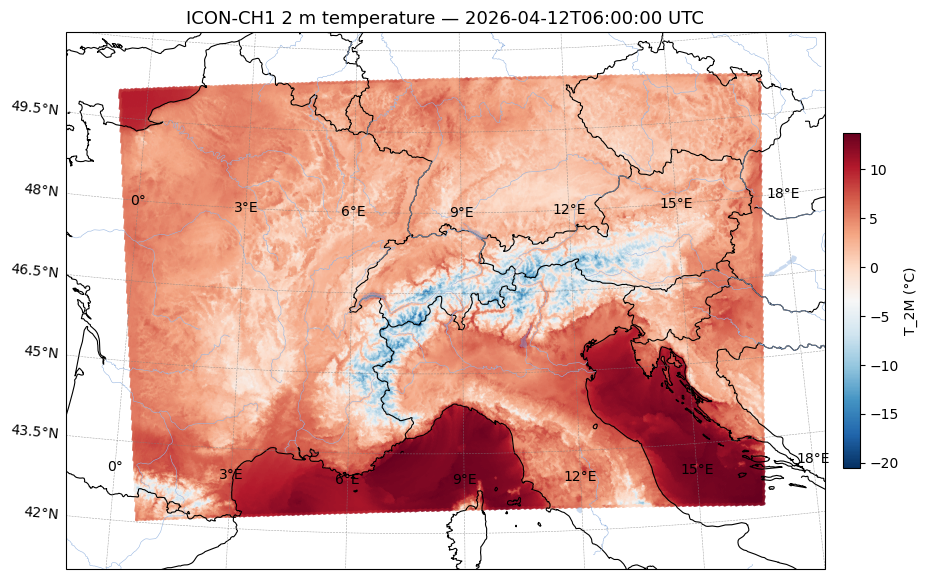

In [ ]:
t2m = (
    ds_ch1_sfc["T_2M"].isel(ref_time=-1).sel(z=2)  # 2 m above ground
    - 273.15  # K → °C
).load()

proj = ccrs.LambertConformal(central_longitude=8.0, central_latitude=47.0)
plate = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": proj})
ax.set_extent([-1, 18, 41.0, 51.0], crs=plate)

sc = ax.scatter(
    ds_ch1_sfc.lon.values,
    ds_ch1_sfc.lat.values,
    c=t2m.values,
    s=0.02,
    cmap="RdBu_r",
    transform=plate,
    rasterized=True,
)

ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, linewidth=0.4)
gl = ax.gridlines(
    draw_labels=True, linewidth=0.4, linestyle="--", color="gray", alpha=0.7
)
gl.top_labels = False
gl.right_labels = False

fig.colorbar(sc, ax=ax, label="T_2M (°C)", shrink=0.5, pad=0.02)
ref = str(ds_ch1_sfc.ref_time.isel(ref_time=-1).values)[:19]
ax.set_title(f"ICON-CH1 2 m temperature — {ref} UTC", fontsize=13)
plt.tight_layout()